<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/Project10_SQL_DataAnalysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# Project 10 - SQL Data Analysis
# Dataset: Superstore Sales
# Source: Kaggle
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
# ================================
# Step 1 - Upload Dataset
# ================================

from google.colab import files
uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [3]:
# ================================
# Step 2 - Load Data & Create SQL Database
# ================================

# Load CSV
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

# Create SQLite Database
conn = sqlite3.connect('superstore.db')
df.to_sql('superstore', conn, if_exists='replace', index=False)

print("\nSQL Database created successfully!")


Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:
   Row ID        Order ID Order Date   Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
1       2  CA-2016-152156  11/8/2016  11/11/2016  Second Class    CG-12520   
2       3  CA-2016-138688  6/12/2016   6/16/2016  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  

In [4]:
# ================================
# Step 3 - SQL Queries
# ================================

def run_query(query, title):
    result = pd.read_sql_query(query, conn)
    print(f"\n{'='*45}")
    print(f"{title}")
    print('='*45)
    print(result.to_string(index=False))
    return result

# Q1: Total Sales & Profit
run_query("""
    SELECT
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit,
        COUNT(*) AS Total_Orders
    FROM superstore
""", "Q1: Overall Business Summary")

# Q2: Sales by Region
run_query("""
    SELECT Region,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", "Q2: Sales & Profit by Region")

# Q3: Top 5 Categories by Sales
run_query("""
    SELECT Category,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(AVG(Profit), 2) AS Avg_Profit
    FROM superstore
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", "Q3: Sales by Category")

# Q4: Top 10 Customers
run_query("""
    SELECT [Customer Name],
        ROUND(SUM(Sales), 2) AS Total_Sales,
        COUNT(*) AS Total_Orders
    FROM superstore
    GROUP BY [Customer Name]
    ORDER BY Total_Sales DESC
    LIMIT 10
""", "Q4: Top 10 Customers")



Q1: Overall Business Summary
 Total_Sales  Total_Profit  Total_Orders
  2297200.86     286397.02          9994

Q2: Sales & Profit by Region
 Region  Total_Sales  Total_Profit
   West    725457.82     108418.45
   East    678781.24      91522.78
Central    501239.89      39706.36
  South    391721.91      46749.43

Q3: Sales by Category
       Category  Total_Sales  Avg_Profit
     Technology    836154.03       78.75
      Furniture    741999.80        8.70
Office Supplies    719047.03       20.33

Q4: Top 10 Customers
     Customer Name  Total_Sales  Total_Orders
       Sean Miller     25043.05            15
      Tamara Chand     19052.22            12
      Raymond Buch     15117.34            18
      Tom Ashbrook     14595.62            10
     Adrian Barton     14473.57            20
      Ken Lonsdale     14175.23            29
      Sanjit Chand     14142.33            22
      Hunter Lopez     12873.30            11
      Sanjit Engle     12209.44            19
Christopher Co

,Customer Name,Total_Sales,Total_Orders
0,Sean Miller,25043.05,15
1,Tamara Chand,19052.22,12
2,Raymond Buch,15117.34,18
3,Tom Ashbrook,14595.62,10
4,Adrian Barton,14473.57,20
5,Ken Lonsdale,14175.23,29
6,Sanjit Chand,14142.33,22
7,Hunter Lopez,12873.30,11
8,Sanjit Engle,12209.44,19
9,Christopher Conant,12129.07,11


In [5]:
# ================================
# Step 4 - Advanced SQL Queries
# ================================

# Q5: Most Profitable Sub-Categories
run_query("""
    SELECT [Sub-Category],
        ROUND(SUM(Profit), 2) AS Total_Profit,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY [Sub-Category]
    ORDER BY Total_Profit DESC
    LIMIT 10
""", "Q5: Top 10 Most Profitable Sub-Categories")

# Q6: Loss Making Sub-Categories
run_query("""
    SELECT [Sub-Category],
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY [Sub-Category]
    HAVING Total_Profit < 0
    ORDER BY Total_Profit ASC
""", "Q6: Loss Making Sub-Categories")

# Q7: Yearly Sales Trend
run_query("""
    SELECT
        SUBSTR([Order Date], -4) AS Year,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Year
    ORDER BY Year
""", "Q7: Yearly Sales Trend")

# Q8: Ship Mode Analysis
run_query("""
    SELECT [Ship Mode],
        COUNT(*) AS Total_Orders,
        ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY [Ship Mode]
    ORDER BY Total_Orders DESC
""", "Q8: Ship Mode Analysis")



Q5: Top 10 Most Profitable Sub-Categories
Sub-Category  Total_Profit  Total_Sales
     Copiers      55617.82    149528.03
      Phones      44515.73    330007.05
 Accessories      41936.64    167380.32
       Paper      34053.57     78479.21
     Binders      30221.76    203412.73
      Chairs      26590.17    328449.10
     Storage      21278.83    223843.61
  Appliances      18138.01    107532.16
 Furnishings      13059.14     91705.16
   Envelopes       6964.18     16476.40

Q6: Loss Making Sub-Categories
Sub-Category  Total_Profit
      Tables     -17725.48
   Bookcases      -3472.56
    Supplies      -1189.10

Q7: Yearly Sales Trend
Year  Total_Sales  Total_Profit
2014    484247.50      49543.97
2015    470532.51      61618.60
2016    609205.60      81795.17
2017    733215.26      93439.27

Q8: Ship Mode Analysis
     Ship Mode  Total_Orders  Total_Sales
Standard Class          5968   1358215.74
  Second Class          1945    459193.57
   First Class          1538    351428.42
 

,Ship Mode,Total_Orders,Total_Sales
0,Standard Class,5968,1358215.74
1,Second Class,1945,459193.57
2,First Class,1538,351428.42
3,Same Day,543,128363.13


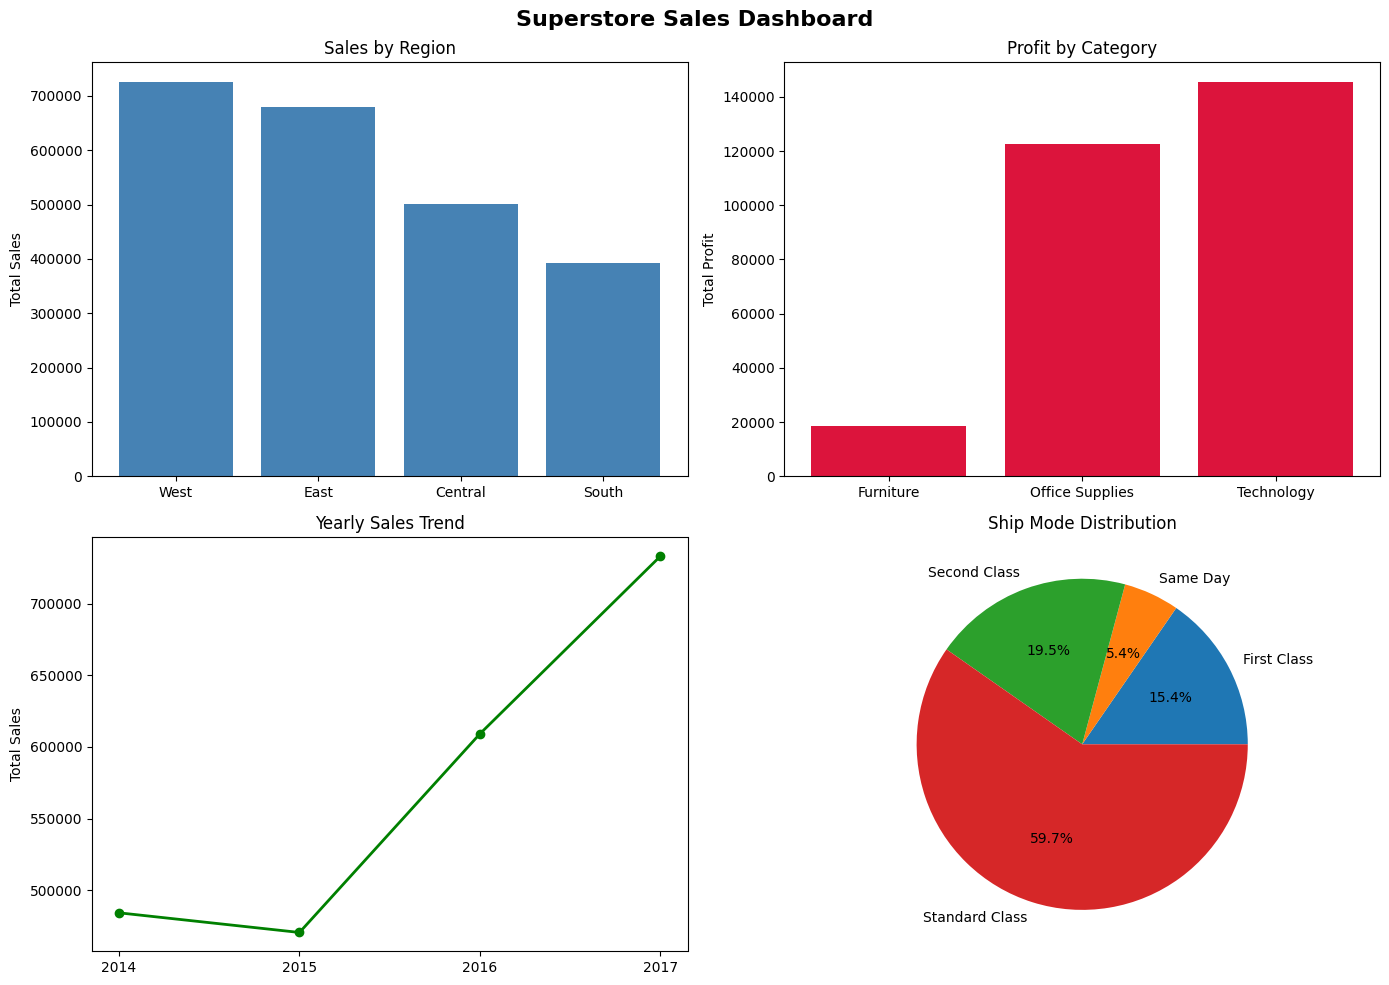

Project Complete!


In [6]:
# ================================
# Step 5 - Visualizations
# ================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sales by Region
region_data = pd.read_sql_query("""
    SELECT Region, ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
axes[0,0].bar(region_data['Region'], region_data['Total_Sales'], color='steelblue')
axes[0,0].set_title('Sales by Region')
axes[0,0].set_ylabel('Total Sales')

# Plot 2: Profit by Category
cat_data = pd.read_sql_query("""
    SELECT Category, ROUND(SUM(Profit),2) AS Total_Profit
    FROM superstore GROUP BY Category
""", conn)
axes[0,1].bar(cat_data['Category'], cat_data['Total_Profit'], color='crimson')
axes[0,1].set_title('Profit by Category')
axes[0,1].set_ylabel('Total Profit')

# Plot 3: Yearly Sales
year_data = pd.read_sql_query("""
    SELECT SUBSTR([Order Date],-4) AS Year,
    ROUND(SUM(Sales),2) AS Total_Sales
    FROM superstore GROUP BY Year ORDER BY Year
""", conn)
axes[1,0].plot(year_data['Year'], year_data['Total_Sales'], marker='o', color='green', linewidth=2)
axes[1,0].set_title('Yearly Sales Trend')
axes[1,0].set_ylabel('Total Sales')

# Plot 4: Ship Mode
ship_data = pd.read_sql_query("""
    SELECT [Ship Mode], COUNT(*) AS Total_Orders
    FROM superstore GROUP BY [Ship Mode]
""", conn)
axes[1,1].pie(ship_data['Total_Orders'], labels=ship_data['Ship Mode'], autopct='%1.1f%%')
axes[1,1].set_title('Ship Mode Distribution')

plt.suptitle('Superstore Sales Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Project Complete!")
